# NLP Project 2

**ESILV A4 DIA6 — 2026**



**Authors:** Leo WINTER & Alvaro SERERO

## Table of Contents   
1. [Setup & Imports](#setup)
2. [Load Data](#load)
3. [model](#w2_vect)

<a id="setup"></a>
## 1. Setup & Imports

In [ ]:
# Faudrait peut-être entrainer les données sur tout le dataset et pas 
# just sur les 20000 car on s'en fout de ne pas avoir les étoiles
# et pour des meilleurs embeddings c'est mieux

from pathlib import Path
import os
import pickle
import ast

import pandas as pd
import numpy as np
from tqdm.auto import tqdm

import gensim.downloader
from gensim.models import Word2Vec
from gensim.models.callbacks import CallbackAny2Vec
from gensim.models import KeyedVectors

from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# Setting up the Paths
CURRENT_DIR = Path.cwd()
DATA_PATH = CURRENT_DIR.parent / "data"
MODEL_PATH = CURRENT_DIR.parent / "model"
VISU_PATH = CURRENT_DIR.parent / "visualizations" / "notebook2"
MODEL_PATH.mkdir(exist_ok=True)
VISU_PATH.mkdir(parents=True, exist_ok=True)

<a id="load"></a>
## 2. Load Data

In [2]:
# Load data saved in the fisrt notebook
def load_data():
    path_parquet = DATA_PATH / "reviews_clean.parquet"
    path_csv = DATA_PATH / "reviews_clean.csv"

    if path_parquet.exists():
        try:
            df = pd.read_parquet(path_parquet)
            return df
        except Exception as e:
            print(e)

    if path_csv.exists():
        try:
            df = pd.read_csv(path_csv)
            return df
        except Exception as e:
            print(e)
    return None

In [3]:
dataset = load_data()
if dataset is not None:
    display(dataset.head(2))
else:
    print("Error, no dataset files found")

,note,auteur,avis,assureur,produit,type,date_publication,date_exp,avis_en,avis_cor,avis_cor_en,year_month,tokens_en,tokens
0,5,brahim--k-131532,"Meilleurs assurances, prix, solutions, écoute,...",Direct Assurance,auto,train,2021-09-06,2021-09-01,"Best insurance, price, solutions, listening, s...",meilleurs assurances prix solutions écoute rap...,best insurance price solutions listening speed...,2021-09,"['good', 'price', 'solution', 'listen', 'speed...","['meilleur', 'prix', 'solution', 'écoute', 'ra..."
1,4,bernard-g-112497,"je suis globalement satisfait , sauf que vous ...",Direct Assurance,auto,train,2021-05-03,2021-05-01,"I am generally satisfied, except that you have...",je suis globalement satisfait sauf que vous av...,i am generally satisfied except that you have ...,2021-05,"['generally', 'satisfied', 'except', 'problem'...","['globalement', 'satisfait', 'sauf', 'problème..."


<a id="w2_vect"></a>
## 3. Word2Vect model

In [52]:
class TqdmCallback(CallbackAny2Vec):
    def __init__(self, total_epochs):
        self.pbar = tqdm(total=total_epochs, desc="Word2Vec")
        self.epoch = 0

    def on_epoch_end(self, model):
        self.epoch += 1
        self.pbar.update(1)
        if self.epoch == self.pbar.total:
            self.pbar.close()

class Word2VecModel:
    def __init__(self, vector_size=100, window=5, min_count=2, sg=1, epochs=10):
        """
        :param vector_size: Vector dimension
        :param window: Contex size
        :param min_count: Minimum apparition of words
        :param sg: 1 for Skip-Gram, 0 for CBOW
        """
        self.vector_size = vector_size
        self.window = window
        self.min_count = min_count
        self.sg = sg
        self.epochs = epochs
        self.model = None

    def train(self, data):
        monitor = TqdmCallback(self.epochs)
        self.model = Word2Vec(
            sentences=data, 
            vector_size=self.vector_size, 
            window=self.window, 
            min_count=self.min_count, 
            workers=4,
            epochs=self.epochs,
            sg=self.sg,
            callbacks=[monitor]
        )
        return self.model

    def save_model(self, file_name):

        if self.model is not None:
            file_path = str(MODEL_PATH / f"{file_name}.model")
            self.model.save(file_path)
            print(f"Model saved")
        else:
            print("Error, no model found")

    def load_model(self, file_name):
        file_path = str(MODEL_PATH / f"{file_name}.model")
        if os.path.exists(file_path):
            self.model = Word2Vec.load(file_path)
            print("Model successfully loaded")
            return self.model
        else:
            print("Model not found")
            
    def get_euclidean_distance(self, word1, word2):
        if self.model is None:
            print("Model not trained")
            return None
        if word1 in self.model.wv and word2 in self.model.wv:
            v1 = self.model.wv[word1]
            v2 = self.model.wv[word2]
            return np.linalg.norm(v1 - v2)
        return None

    def get_cosine_similarity(self, word1, word2):
        if self.model is None:
            print("Model not trained")
            return None
        if word1 in self.model.wv and word2 in self.model.wv:
            v1 = self.model.wv[word1]
            v2 = self.model.wv[word2]
            return np.dot(v1, v2) / (np.linalg.norm(v1) * np.linalg.norm(v2))
        return None
    
    def plot_2d_embeddings(self, words_to_plot, name: str = "2D_embeddings"):
        if self.model is None:
            print("Model not trained")
            return None

        vectors = [self.model.wv[w] for w in words_to_plot if w in self.model.wv]
    
        pca = PCA(n_components=2)
        result = pca.fit_transform(vectors)
    
        plt.scatter(result[:, 0], result[:, 1])
        for i, word in enumerate(words_to_plot):
            plt.annotate(word, xy=(result[i, 0], result[i, 1]))
        plt.title(f"2D word embeddings")
        plt.savefig(VISU_PATH / f"{name}.png", bbox_inches="tight")
        plt.show()
    
    def get_sentence_vector(self, sentence):
        if self.model is None:
            print("Model not trained")
            return None
        
        words = sentence.split() if isinstance(sentence, str) else sentence
        valid_vectors = [self.model.wv[w] for w in words if w in self.model.wv]
        if not valid_vectors:
            return None
    
        return np.mean(valid_vectors, axis=0)
    

    def semantic_search(self, query, corpus_vectors, top_n=3):
        if self.model is None:
            print("Model not trained")
            return None
        
        query_vec = self.get_sentence_vector(query)
        if query_vec is None: return "Unknown word"
    
        similarities = []
        for doc_vec in corpus_vectors:
            sim = np.dot(query_vec, doc_vec) / (np.linalg.norm(query_vec) * np.linalg.norm(doc_vec))
            similarities.append(sim)

        return np.argsort(similarities)[-top_n:][::-1]


<a id="w2_vect_training"></a>
### 3.1 Training 

In [ ]:
if dataset is not None:

    data_pour_w2v_en = [ast.literal_eval(text) 
                        if isinstance(text, str) 
                        else text for text in dataset['tokens_en']]
    data_pour_w2v_fr = [ast.literal_eval(text) 
                        if isinstance(text, str) 
                        else text for text in dataset['tokens']]

    model_w2v_en = Word2VecModel()
    model_w2v_fr = Word2VecModel()

    model_w2v_en.train(data_pour_w2v_en)
    model_w2v_fr.train(data_pour_w2v_fr)

    model_w2v_en.save_model("word2vec_en")
    model_w2v_fr.save_model("word2vec_fr")

Word2Vec: 100%|██████████| 10/10 [00:14<00:00,  1.45s/it]

Model saved
Model saved


<a id="w2_vect_testing"></a>
### 3.2 Test

In [54]:
try:
    if model_w2v_fr.model is None:
        model_w2v_fr.load_model("word2vec_fr")
except NameError:
    model_w2v_fr = Word2VecModel()
    model_w2v_fr.load_model("word2vec_fr")

try:
    if model_w2v_en.model is None:
        model_w2v_en.load_model("word2vec_en")
except NameError:
    model_w2v_en = Word2VecModel()
    model_w2v_en.load_model("word2vec_en")

Model successfully loaded
Model successfully loaded


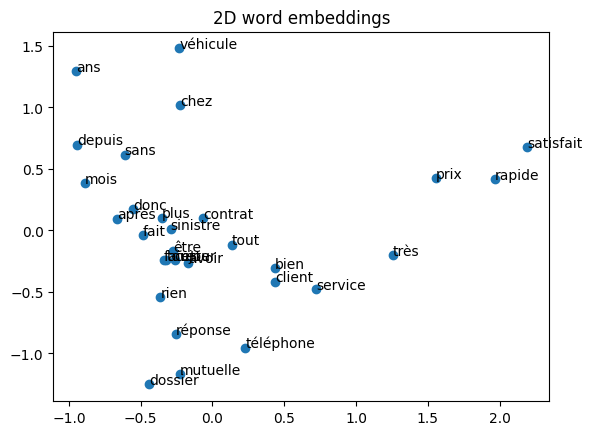

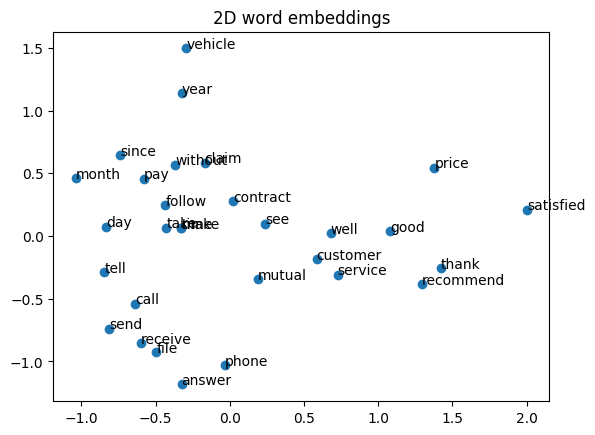

In [36]:
model_w2v_fr.plot_2d_embeddings(model_w2v_fr.model.wv.index_to_key[:30]
                                ,"Top_word_2D_embeddings_w2v_fr")
model_w2v_en.plot_2d_embeddings(model_w2v_en.model.wv.index_to_key[:30]
                                ,"Top_word_2D_embeddings_w2v_en")

In [50]:
sim_good_en = model_w2v_en.get_cosine_similarity("price", "attractive")
dist_good_en = model_w2v_en.get_euclidean_distance("price", "attractive")
sim_good_fr = model_w2v_fr.get_cosine_similarity("prix", "attractif")
dist_good_fr = model_w2v_fr.get_euclidean_distance("prix", "attractif")

sim_bad_en = model_w2v_en.get_cosine_similarity("price", "answer")
dist_bad_en = model_w2v_en.get_euclidean_distance("price", "answer")
sim_bad_fr = model_w2v_fr.get_cosine_similarity("prix", "réponse")
dist_bad_fr = model_w2v_fr.get_euclidean_distance("prix", "réponse")


print(f"                             English model")
print((f"Price vs Attractive | Cosinus sim: {sim_good_en:.4f}"
       f"| Euclidienne dist: {dist_good_en:.4f}"))
print((f"Price vs Answer    | Cosinus sim: {sim_bad_en:.4f}"
       f"| Euclidienne dist: {dist_bad_en:.4f}"))

print(f"\n                             French model")
print((f"Prix vs Attractif | Cosinus sim: {sim_good_fr:.4f}"
       f"| Euclidienne dist: {dist_good_fr:.4f}"))
print((f"Prix vs Réponse   | Cosinus sim: {sim_bad_fr:.4f}"
       f"| Euclidienne dist: {dist_bad_fr:.4f}"))

                             English model
Price vs Attractive | Cosinus sim: 0.7125| Euclidienne dist: 2.4134
Price vs Answer    | Cosinus sim: 0.2866| Euclidienne dist: 3.3982

                             French model
Prix vs Attractif | Cosinus sim: 0.6655| Euclidienne dist: 2.7223
Prix vs Réponse   | Cosinus sim: 0.2496| Euclidienne dist: 3.9338


In [69]:
all_vectors_raw_en = [model_w2v_en.get_sentence_vector(rev) for rev in data_pour_w2v_en]
valid_data_en = {i: vec for i, vec in enumerate(all_vectors_raw_en) if vec is not None}
clean_vectors_en = list(valid_data_en.values())
clean_indices_en = list(valid_data_en.keys())

all_vectors_raw_fr = [model_w2v_en.get_sentence_vector(rev) for rev in data_pour_w2v_en]
valid_data_fr = {i: vec for i, vec in enumerate(all_vectors_raw_fr) if vec is not None}
clean_vectors_fr = list(valid_data_fr.values())
clean_indices_fr = list(valid_data_fr.keys())

In [72]:
query = "very expensive insurance"
results = model_w2v_en.semantic_search(query, clean_vectors_en)

print(f"        Query <{query}> :\n")
for rank, idx_in_clean in enumerate(results):
    original_idx = clean_indices_en[idx_in_clean]
    avis_texte = dataset['tokens_en'].iloc[original_idx]
    print(f"Top {rank+1}-Avis n°{original_idx}: {avis_texte}")

print("\n\n")
query = "assurance très chère"
results = model_w2v_fr.semantic_search(query, clean_vectors_fr)

print(f"        Query <{query}> :\n")
for rank, idx_in_clean in enumerate(results):
    original_idx = clean_indices_fr[idx_in_clean]
    avis_texte = dataset['tokens'].iloc[original_idx]
    print(f"Top {rank+1}-Avis n°{original_idx}: {avis_texte}")

        Query <very expensive insurance> :

Top 1-Avis n°14121: ['far', 'expensive']
Top 2-Avis n°5405: ['price', 'expensive', 'think', 'chef', 'expensive', 'france', 'french', 'increasingly', 'poor', 'think', 'price', 'expensive']
Top 3-Avis n°21372: ['expensive', 'gan', 'service']



        Query <assurance très chère> :

Top 1-Avis n°5670: ['client', 'cetera', 'depuis', 'maintenant', 'ans', 'divorcé', 'chômage', 'changer', 'département', 'après', 'avoir', 'fais', 'plusieur', 'courri', 'résiliation', 'refusent', 'résiliation', 'disent', 'groupement', 'mutuelle', 'donc', 'tiennent', 'compte', 'législation', 'vigueur', 'aussi', 'envoyer', 'depuis', 'ans', 'deux', 'mois', 'avant', 'déchéance', 'contrat', 'comme', 'stipuler', 'dan', 'cru', 'trouvent', 'toujours', 'prétexte', 'trop', 'tôt', 'trop', 'tard', 'aujourd', 'hui', 'passe', 'cru', 'compte', 'tenu', 'ressource', 'plus', 'couvert', 'cru', 'chez', 'aussi', 'changer', 'compte', 'bancaire', 'cetera', 'prélève', 'bien', 'argent', 'tou

<a id="model"></a>
## 3. Glove model

This time we will take an already trained model for our dataset

In [ ]:
class gensim_interface:
    def embeddingPreparation(self,embeddingName):
        self.embeddingVectors = gensim.downloader.load(embeddingName)
        with open(embeddingName + ".vecs","wb") as fd:
            pickle.dump(self.embeddingVectors,fd)

    #input: name of the embedding wanted (example : 'glove-twitter-25')
    def loadPreparedEmbedding(self,embeddingName):
        with open(embeddingName + ".vecs","rb") as fd:
            self.embeddingVectors = pickle.load(fd)

    #input: word or id of the word
    #output: True if word in the embedding list, False otherwise
    def isVec(self,word):
        if word in self.embeddingVectors:
            return True
        else:
            return False

    #input: word(string) or word id(int)
    #output: vector embedding
    def getVec(self,word):
        return self.embeddingVectors[word]

    #input: word(string)
    #output: word id(int)
    def getId(self,word):
        return self.embeddingVectors.key_to_index[word]

    #input: word id(int)
    #output: word(string)
    def getWord(self,id):
        return self.embeddingVectors.index_to_key[id]

    #output : list of all words covered by the embedding
    def getVocabList(self):
        return self.embeddingVectors.index_to_key

    #output : return vocabulary dictionary associating word and idWords (key=word, value=idWord)
    def getVocabDic(self):
        return self.embeddingVectors.key_to_index

    #output : number of words covered by the embedding
    def getLenVocab(self):
        return len(self.embeddingVectors.index_to_key)

    #output :  number of dimensions of the embedding
    def nbDims(self):
        return self.embeddingVectors.vector_size

    #output : list of all embeddings names availables on gensim
    def getAvailableEmbeddings(self):
        return list(gensim.downloader.info()['models'].keys())

    #input : word , number of most similar words wanted
    #output : list of n most similar words
    def getMostSimilar(self,word,n):
        ms = self.embeddingVectors.most_similar(word,topn=n)
        neighbours = [elem[0] for elem in ms]
        return neighbours
    
    def __init__(self,embeddingName):
        #test if file exists
        fileName = embeddingName + ".vecs"
        if os.path.isfile(fileName):
            print("loading embeddings...")
            self.loadPreparedEmbedding(embeddingName)
        else:
            print("embedding preparation...")
            self.embeddingPreparation(embeddingName)
        self.vectors = self.embeddingVectors.vectors
